# Prosjekt 3

In [3]:
# Biblioteker
import numpy as np
import matplotlib.pyplot as plt
import scipy

## Oppgave 1

### Oppgave 1a)

$ \frac{d^2 y}{(d x)^2}  = -4 * \sin(2x)$

Flytter dx^2 over på høyre side og integrerer to ganger.

$ \int{dy^2} = \int{-4*\sin(2x) dx^2} $

$dy = (4 * \frac{1}{2} \sin(2x) + C)dx$

$\int{dy} = \int{(4 * \frac{1}{2} \sin(2x) + C)dx}$ 


### Oppgave 1b)

### Oppgave 1c)

In [73]:
def f(x, y):
    return np.array([y[1], -4 * np.sin(2*x)])

def rk3 (x_start, x_slutt, y_0, h_0, tol, alpha, f):
   
    n, m = 0, 0                         # teller for antall godkjente steg (n) og ikke godkjente (m)
    x_verdier = np.array([x_start])     # array til x-verdier      
    y_verdier = np.array([y_0])         # array for y' og y
    h_verdier = np.array([])            # array til å lagre steglengde

    # Verdier som skal bli oppdatert i while-løkken
    x = x_start
    y = np.array(y_0)
    k1 = f(x,y)
    h = h_0
    
    while (x_slutt - x) > 0:

        # Velger steglengde
        h = min(h, x_slutt - x)

        k2 = f(x +h/2, y+ h*k1/2)
        k3 = f(x + 3*h/4, y + 3*h*k2/4)

        y_neste = y + h* (2*k1 + 3*k2 + 4*k3)/9             # y[n+1]

        k4 = f(x + h, y_neste) 

        z_neste = y + 1/24*h*(7*k1 + 6*k2 + 8*k3 + 3*k4)    # z[n+1]

        est = np.linalg.norm(y_neste - z_neste)             # || y[n+1] - z[n+1] ||
        
        if est < tol:       # Akseptert steg
            x += h
            y = y_neste
            k1 = k4
            n += 1
            # Lagrer steget og tilhørende verdier:  
            x_verdier = np.append(x_verdier, x)
            y_verdier = np.append(y_verdier, [y], axis=0)
            h_verdier = np.append(h_verdier, h)
        else:               
            m += 1          # Ikke akseptert steg

        # Regn ut h_ny og la h = h_ny:
        h_ny = alpha * h *(tol/est)**(1/3)
        h = h_ny
    
    return x_verdier, y_verdier, h_verdier, n, m

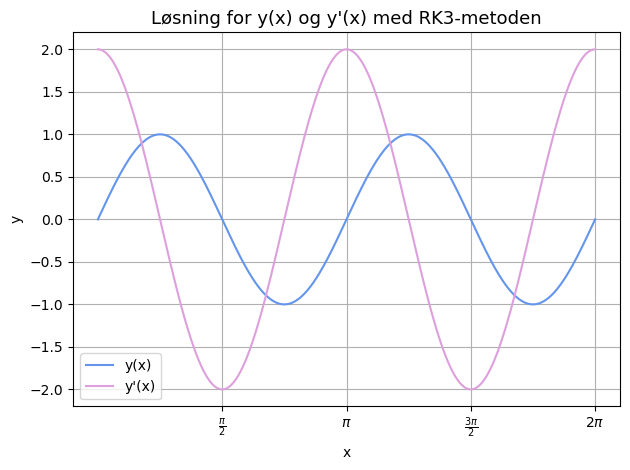

In [80]:
# Verdier
x_start = 0
x_slutt = 2*np.pi
h_0 = np.pi / 100
y_0 = np.array([0, 2])
alpha = 0.8
tol = 10e-7

x_verdier, y_verdier, h_verdier, n, m = rk3(x_start, x_slutt, y_0, h_0, tol, alpha, f)

# Plot for y(x) og y'(x)
plt.plot(x_verdier, y_verdier[:,0], color = "cornflowerblue", label = "y(x)")
plt.plot(x_verdier, y_verdier[:,1], color = "plum", label = "y'(x)")

plt.title("Løsning for y(x) og y'(x) med RK3-metoden", size = 13)
plt.xlabel("x")     # HVA SKAL AKSENAVNENE VÆRE?
plt.ylabel("y")

# Endrer x-aksen til å ha pi
ticks = [0.5*np.pi, np.pi, 1.5*np.pi, 2*np.pi]
labels = [r'$\frac{\pi}{2}$', r'$\pi$', r'$\frac{3\pi}{2}$', r'$2\pi$']
plt.xticks(ticks, labels)

plt.tight_layout()
plt.grid(True)
plt.legend()
plt.show()

De analytiske løsningene av $y(x)$ og $y'(x)$ er (fra oppgave 1a): 

$ y(x) = \sin(2x)$ og $y'(x) = 2*\cos(2x)$

Den numeriske løsningen av $y(x)$ (blå graf) er en sinuskurve med amplitude 1, den går mellom [-1, 1]. Den oscillerer dobbelt så raskt som $\sin(x)$, dette er fordi argumentet $2x$ gir den en periode på $\pi$. Derfor ser vi to svingninger på intervallet $[0, 2\pi]$.
Grafen til $y'(x)$ (lilla) er en cosinuskurve med samme frekvens og dobbel amplitude av $y(x)$. Ekstremalpunktene til $y(x)$ svarer til nullpunktene i $y'(x)$.

Den numeriske løsningen stemmer overens med den analytiske, og RK3-metoden gir en nøyaktig tilnærming i dette tilfellet.

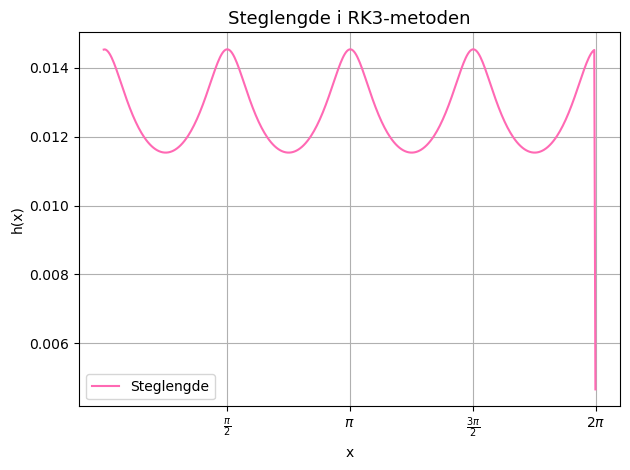

In [78]:
# Plot for steglengde
plt.plot(x_verdier[:-1], h_verdier, label = "Steglengde", color = "hotpink")
plt.title("Steglengde i RK3-metoden", size = 13)
plt.ylabel("h(x)")
plt.xlabel("x")

# Endrer x-aksen til å ha pi
ticks = [0.5*np.pi, np.pi, 1.5*np.pi, 2*np.pi]
labels = [r'$\frac{\pi}{2}$', r'$\pi$', r'$\frac{3\pi}{2}$', r'$2\pi$']
plt.xticks(ticks, labels)

plt.tight_layout()
plt.grid(True)
plt.legend()
plt.show()

Frem til siste steget varierer steglengden $h(x)$ tilnærmet periodisk. Dette skyldes at løsningen endrer seg med varierende krummning. Når det er stor krummning, blir den lokale feilen større for en gitt $h$ og RK3-metoden må derfor redusere $h$ for å holde feilen under toleransen. I omeråder der løsningen er tilnærmet linær kan metoden bruke større steglengder.

RK3-metoden sjekker steglengden på hver iterasjon slik at $h$ ikke overskrider sluttpunktet $x_{slutt}$. I hvert steg settes derfor $h = min(h, x_{slutt} - x)$. 
I det siste steget vil dette føre til at $h$ blir lik avstanden til sluttpunktet. Denne steglengden vil avvike fra det tidligere mønsteret og grafen får derfor en "dupp" i siste steg.

### Oppgave 1d

498
498


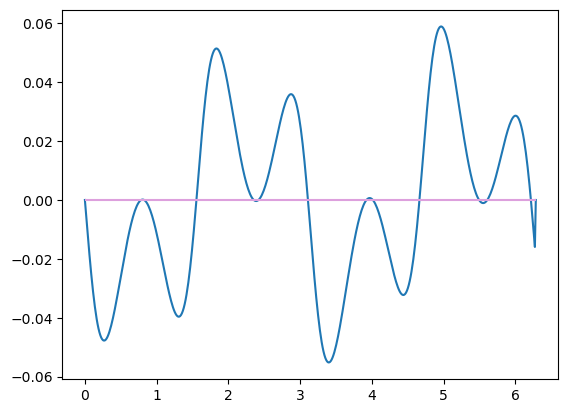

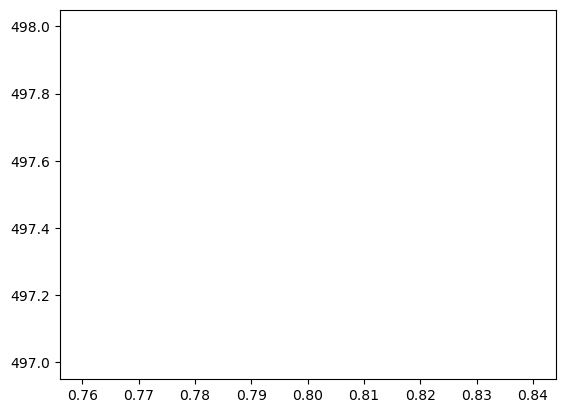

In [94]:
x_verdier1 = np.linspace(0, 2*np.pi, n+1) #n hentes fra oppgave 1c (rk3)
def y_anal (x):
    return np.sin(2*x)

y_anal_verdier = y_anal(x_verdier1)

error = y_anal_verdier - y_verdier[:,0]

print(y_anal_verdier.size)
print(y_verdier[:,0].size)

plt.plot(x_verdier1, error)
plt.hlines(tol, x_start, x_slutt, color = 'plum')
plt.show()

alphas = np.linspace
plt.plot(alpha,n , color = 'r')
plt.plot(alpha, m, color = 'b')
plt.show()

###     Oppgave 1e)

In [81]:
def g(z):
    return z + np.sin(z) + np.cos(z)

def sekant_metoden (g, z0, z1, tol):
    z = [z0, z1]

    # Løser for z[2] utenfor løkken, ellers får man out of range pga. abs(z[n-1] - z[n])       
    n = 2
    z.append((z[n-2]*g(z[n-1]) - z[n-1]*g(z[n-2])) / (g(z[n-1]) - g(z[n-2])))

    while abs(z[n-1] - z[n]) > tol:
        n+=1
        z.append((z[n-2]*g(z[n-1]) - z[n-1]*g(z[n-2])) / (g(z[n-1]) - g(z[n-2])))
        
        #print(f"\nAbsolutt verdi i {n}: {abs(z[n-1] - z[n])}")
        #print(f"z[n] = {z[n]}")
        
    g_rot = z[-1]
    return g_rot

# startverdier
z_0 = 0
z_1 = 4
tol = 10e-10

# Finner roten til g(z) = z + sin(z) + cos(z)
g_rot = sekant_metoden (g, z_0, z_1, tol)
print(f"Roten til g(z) = z + sin(z) + cos(z) er {g_rot:.5f}")


Roten til g(z) = z + sin(z) + cos(z) er -0.45662


### Oppgave 1f)

In [92]:
# løser IVP for en gitt ukjent startverdi b
def løs_med_b (b):
    y_0 = np.array([0, b])
    x_verdier_f, y_verdier_f, h, n = rk3(x_start, x_slutt, y_0, h_0, tol, alpha, f)

    return y_verdier_f[-1, 0] # = y(b)    [siste rad = b, første kolonne = y]

# Residual, F(s) - s
def residual(s):
    # B er ønsket verdi y(b)
    return løs_med_b(s)

# Verdier
b0 = 0          # b er verdien som gir yb(2pi) = 0
b1 = np.pi
y_0 = 0
y_2pi = 0
x_start = 0
x_slutt = 2*np.pi
h_0 = np.pi / 100
alpha = 0.8
tol = 10e-7

# finn rett b
riktig_b = sekant_metoden(residual, b0, b1, tol)

# løs med riktig b
y_0_rett = np.array([0, riktig_b])
x_verdier_f, y_verdier_f, h, n = rk3(x_start, x_slutt, y_0, h_0, tol, alpha, f)

plt.plot(x_verdier_f, y_verdier_f)
plt.show()

TypeError: can't multiply sequence by non-int of type 'float'

### Oppgave 1h)

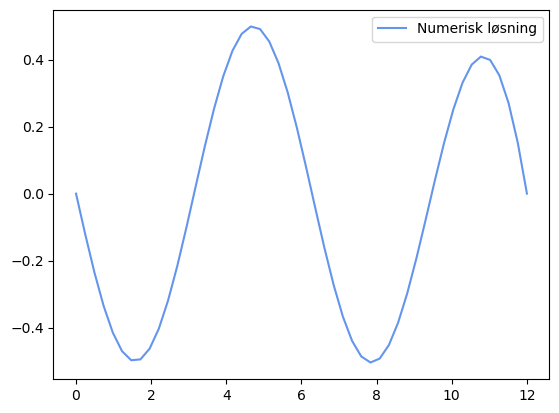

In [90]:
#Use the scipy function solve_bvp to solve eq. from task 1g)
from scipy.integrate import solve_bvp

def f(x, y):
    return [y[1], y[0]+ np.sin(x)]

#Grensebetingelser: y(0) = y(12) = 0
def bc(ya, yb):
    return [ya[0]-0, yb[0]-0]


x = np.linspace(0, 12)

y_init = np.zeros((2, x.size))
#y_init[0] = np.linspace(0, 1, x.size)
#y_init[1] = np.zeros(x.size)

sol = solve_bvp(f, bc, x, y_init)

x_plot = np.linspace(0, 12)
y_plot = sol.sol(x_plot)[0]

plt.plot(x_plot, y_plot, label = 'Numerisk løsning', color = 'cornflowerblue')
plt.legend()
plt.show()


